# 问题二：投票结合方式分析

## 问题描述
分析两种投票结合方式（排名法vs百分比法）的区别，以及评委打破平局规则的影响。

## 核心任务
1. 比较两种投票方式产生的结果差异
2. 分析争议选手在不同方式下的命运
3. 评估评委打破平局规则的影响

## 建模方法
- **反事实分析**：将两种方法应用于所有季
- **因果推断**：分析方法选择对结果的影响

In [1]:
# ===== O奖级全局设置 =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

COLORS = {
    'primary': '#2E5B88',
    'secondary': '#E85D4C',
    'tertiary': '#4A9B7F',
    'neutral': '#7F7F7F',
    'light': '#B8D4E8',
}

FIG_DOUBLE = (10, 4)
FIG_SINGLE = (5, 4)

print('环境配置完成')

环境配置完成


## 第一步：加载数据

In [2]:
# 加载数据
df_long = pd.read_csv('../数据预处理/data_long_format.csv')
vote_estimates = pd.read_csv('../问题一/vote_estimates.csv')

print(f'长格式数据: {df_long.shape}')
print(f'投票估算数据: {vote_estimates.shape}')

# 合并投票估算
df_analysis = df_long.merge(
    vote_estimates[['celebrity_name', 'season', 'week', 'estimated_vote_share', 'popularity_factor']],
    on=['celebrity_name', 'season', 'week'],
    how='left'
)
df_analysis['estimated_vote_share'] = df_analysis['estimated_vote_share'].fillna(df_analysis['judge_score_pct']/100)

print(f'合并后数据: {len(df_analysis)} 条')

长格式数据: (2777, 28)
投票估算数据: (2777, 9)
合并后数据: 2777 条


## 第二步：方法定义与应用

### 2.1 排名法（Rank-Based Method）
$$C_i^{rank} = R_i^{judge} + R_i^{fan}$$

### 2.2 百分比法（Percentage-Based Method）
$$C_i^{pct} = P_i^{judge} + P_i^{fan}$$

In [3]:
def apply_rank_method(group):
    """应用排名法计算综合得分"""
    judge_ranks = stats.rankdata(-group['total_score'].values)
    fan_ranks = stats.rankdata(-group['estimated_vote_share'].values)
    combined = judge_ranks + fan_ranks
    group = group.copy()
    group['rank_combined'] = combined
    group['rank_eliminated'] = combined == combined.max()
    return group

def apply_percentage_method(group):
    """应用百分比法计算综合得分"""
    judge_pct = group['total_score'].values / group['total_score'].sum()
    fan_pct = group['estimated_vote_share'].values / group['estimated_vote_share'].sum()
    combined = judge_pct + fan_pct
    group = group.copy()
    group['pct_combined'] = combined
    group['pct_eliminated'] = combined == combined.min()
    return group

# 对所有周应用两种方法
print('应用两种投票方式...')
results = []
for (season, week), group in df_analysis.groupby(['season', 'week']):
    if len(group) < 2:
        continue
    group = apply_rank_method(group)
    group = apply_percentage_method(group)
    results.append(group)

df_compared = pd.concat(results, ignore_index=True)
print(f'处理完成: {len(df_compared)} 条记录')

应用两种投票方式...
处理完成: 2777 条记录


## 第三步：方法差异分析

In [4]:
def analyze_method_differences(df):
    """分析两种方法的淘汰差异"""
    differences = []
    
    for (season, week), group in df.groupby(['season', 'week']):
        if len(group) < 2:
            continue
        
        rank_elim = group[group['rank_eliminated']]['celebrity_name'].tolist()
        pct_elim = group[group['pct_eliminated']]['celebrity_name'].tolist()
        actual_elim = group[group['is_eliminated']]['celebrity_name'].tolist()
        
        same_elimination = set(rank_elim) == set(pct_elim)
        
        differences.append({
            'season': season,
            'week': week,
            'rank_eliminated': rank_elim[0] if rank_elim else None,
            'pct_eliminated': pct_elim[0] if pct_elim else None,
            'actual_eliminated': actual_elim[0] if actual_elim else None,
            'same_method_result': same_elimination,
            'n_contestants': len(group)
        })
    
    return pd.DataFrame(differences)

method_diff = analyze_method_differences(df_compared)

print('='*60)
print('【方法差异分析】')
print('='*60)
print(f'总验证周数: {len(method_diff)}')
print(f'两种方法结果相同: {method_diff["same_method_result"].sum()} ({method_diff["same_method_result"].mean()*100:.1f}%)')

【方法差异分析】
总验证周数: 335
两种方法结果相同: 320 (95.5%)


## 第四步：争议选手分析

In [5]:
controversial = ['Jerry Rice', 'Billy Ray Cyrus', 'Bristol Palin', 'Bobby Bones']

controversial_analysis = []
for name in controversial:
    data = df_compared[df_compared['celebrity_name'] == name]
    if len(data) > 0:
        rank_elim_count = data['rank_eliminated'].sum()
        pct_elim_count = data['pct_eliminated'].sum()
        actual_final = data['placement'].iloc[0]
        
        controversial_analysis.append({
            'celebrity': name,
            'season': data['season'].iloc[0],
            'weeks_competed': len(data),
            'final_placement': actual_final,
            'avg_judge_rank': data['judge_rank'].mean(),
            'rank_method_eliminations': rank_elim_count,
            'pct_method_eliminations': pct_elim_count,
            'favors_method': 'rank' if rank_elim_count < pct_elim_count else ('percentage' if pct_elim_count < rank_elim_count else 'equal')
        })

df_controversial = pd.DataFrame(controversial_analysis)

print('='*60)
print('【争议选手分析】')
print('='*60)
print(df_controversial.to_string())

【争议选手分析】
         celebrity  season  weeks_competed  final_placement  avg_judge_rank  rank_method_eliminations  pct_method_eliminations favors_method
0       Jerry Rice       2               8                2        4.625000                         3                        3         equal
1  Billy Ray Cyrus       4               8                5        6.500000                         4                        3    percentage
2    Bristol Palin      11              14                3        7.214286                         9                        9         equal
3      Bobby Bones      27               9                1        7.000000                         2                        2         equal


## 第五步：评委打破平局规则分析

In [6]:
def simulate_tiebreaker(df, bottom_n=2):
    """模拟评委从底部N位中选择淘汰者"""
    results = []
    
    for (season, week), group in df.groupby(['season', 'week']):
        if len(group) < bottom_n + 1:
            continue
        
        group = group.sort_values('pct_combined')
        bottom_contestants = group.head(bottom_n)
        
        judge_choice = bottom_contestants.loc[bottom_contestants['total_score'].idxmin()]
        fan_choice = bottom_contestants.loc[bottom_contestants['estimated_vote_share'].idxmin()]
        
        actual_eliminated = group[group['is_eliminated'] == True]
        
        results.append({
            'season': season,
            'week': week,
            'judge_tiebreaker_choice': judge_choice['celebrity_name'],
            'pure_fan_choice': fan_choice['celebrity_name'],
            'actual_eliminated': actual_eliminated['celebrity_name'].values[0] if len(actual_eliminated) > 0 else None,
            'tiebreaker_changes_result': judge_choice['celebrity_name'] != fan_choice['celebrity_name']
        })
    
    return pd.DataFrame(results)

tiebreaker_analysis = simulate_tiebreaker(df_compared)

print('='*60)
print('【评委打破平局分析】')
print('='*60)
print(f'评委打破平局改变结果: {tiebreaker_analysis["tiebreaker_changes_result"].mean()*100:.1f}%')

【评委打破平局分析】
评委打破平局改变结果: 3.9%


## 第六步：方法偏向性分析

In [7]:
def calculate_method_bias(df):
    """计算方法对粉丝投票vs评委得分的偏向"""
    bias_results = []
    
    for (season, week), group in df.groupby(['season', 'week']):
        if len(group) < 3:
            continue
        
        rank_fan_corr = np.corrcoef(
            stats.rankdata(-group['estimated_vote_share'].values),
            group['rank_combined'].values
        )[0,1]
        
        pct_fan_corr = np.corrcoef(
            group['estimated_vote_share'].values,
            group['pct_combined'].values
        )[0,1]
        
        bias_results.append({
            'season': season,
            'week': week,
            'rank_fan_influence': -rank_fan_corr,
            'pct_fan_influence': pct_fan_corr,
            'n_contestants': len(group)
        })
    
    return pd.DataFrame(bias_results)

bias_analysis = calculate_method_bias(df_compared)

print('='*60)
print('【方法偏向性分析】')
print('='*60)
print(f'排名法粉丝影响力: {bias_analysis["rank_fan_influence"].mean():.3f}')
print(f'百分比法粉丝影响力: {bias_analysis["pct_fan_influence"].mean():.3f}')

【方法偏向性分析】
排名法粉丝影响力: -0.841
百分比法粉丝影响力: 0.766


## 第七步：可视化分析

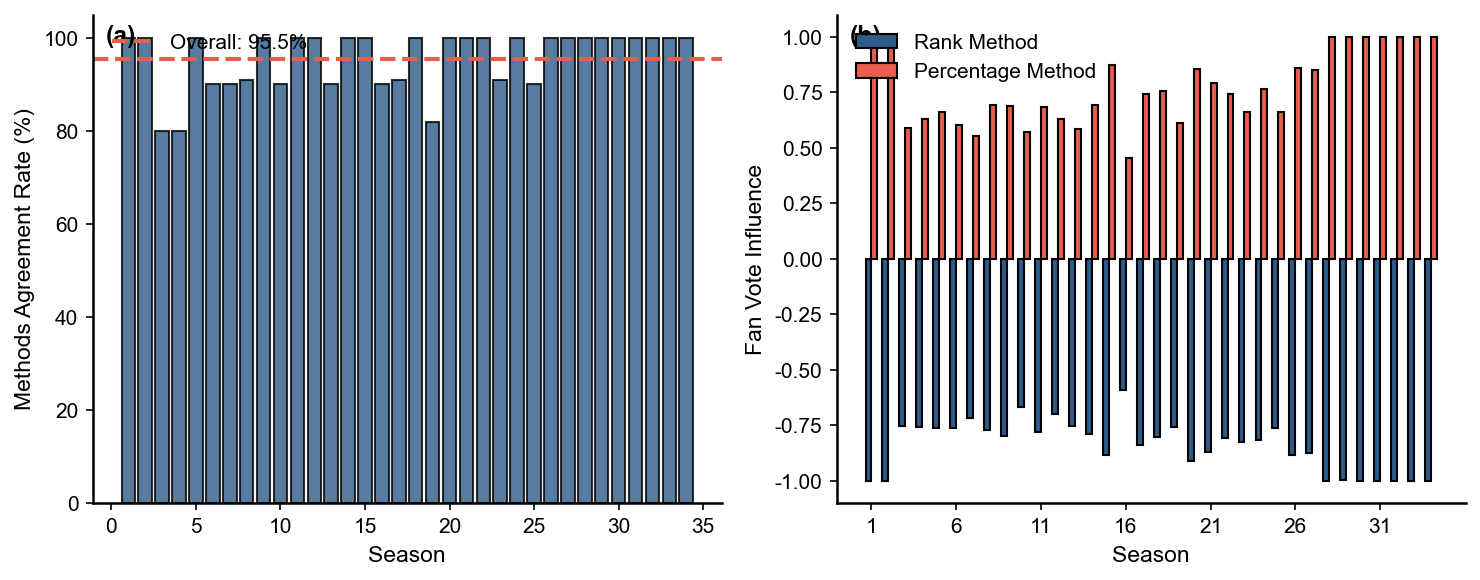

【图1数据特征 - 方法比较】
   总体一致率: 95.5%
   按季一致率范围: [80.0%, 100.0%]


In [8]:
# ============ 图1: 方法比较 ============
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

# 1a: 两种方法结果一致性按季
consistency_by_season = method_diff.groupby('season')['same_method_result'].mean() * 100
axes[0].bar(consistency_by_season.index, consistency_by_season.values, 
           color=COLORS['primary'], edgecolor='black', alpha=0.8)
axes[0].axhline(y=method_diff['same_method_result'].mean()*100, color=COLORS['secondary'], 
               linestyle='--', linewidth=2, label=f'Overall: {method_diff["same_method_result"].mean()*100:.1f}%')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Methods Agreement Rate (%)')
axes[0].legend()
axes[0].text(0.02, 0.98, '(a)', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')

# 1b: 方法偏向性比较
fan_influence = bias_analysis.groupby('season')[['rank_fan_influence', 'pct_fan_influence']].mean()
x = np.arange(len(fan_influence))
width = 0.35
axes[1].bar(x - width/2, fan_influence['rank_fan_influence'], width, 
           label='Rank Method', color=COLORS['primary'], edgecolor='black')
axes[1].bar(x + width/2, fan_influence['pct_fan_influence'], width, 
           label='Percentage Method', color=COLORS['secondary'], edgecolor='black')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Fan Vote Influence')
axes[1].set_xticks(x[::5])
axes[1].set_xticklabels(fan_influence.index[::5])
axes[1].legend()
axes[1].text(0.02, 0.98, '(b)', transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('figures/fig1_method_comparison.pdf', format='pdf')
plt.show()

print('='*60)
print('【图1数据特征 - 方法比较】')
print(f'   总体一致率: {method_diff["same_method_result"].mean()*100:.1f}%')
print(f'   按季一致率范围: [{consistency_by_season.min():.1f}%, {consistency_by_season.max():.1f}%]')
print('='*60)

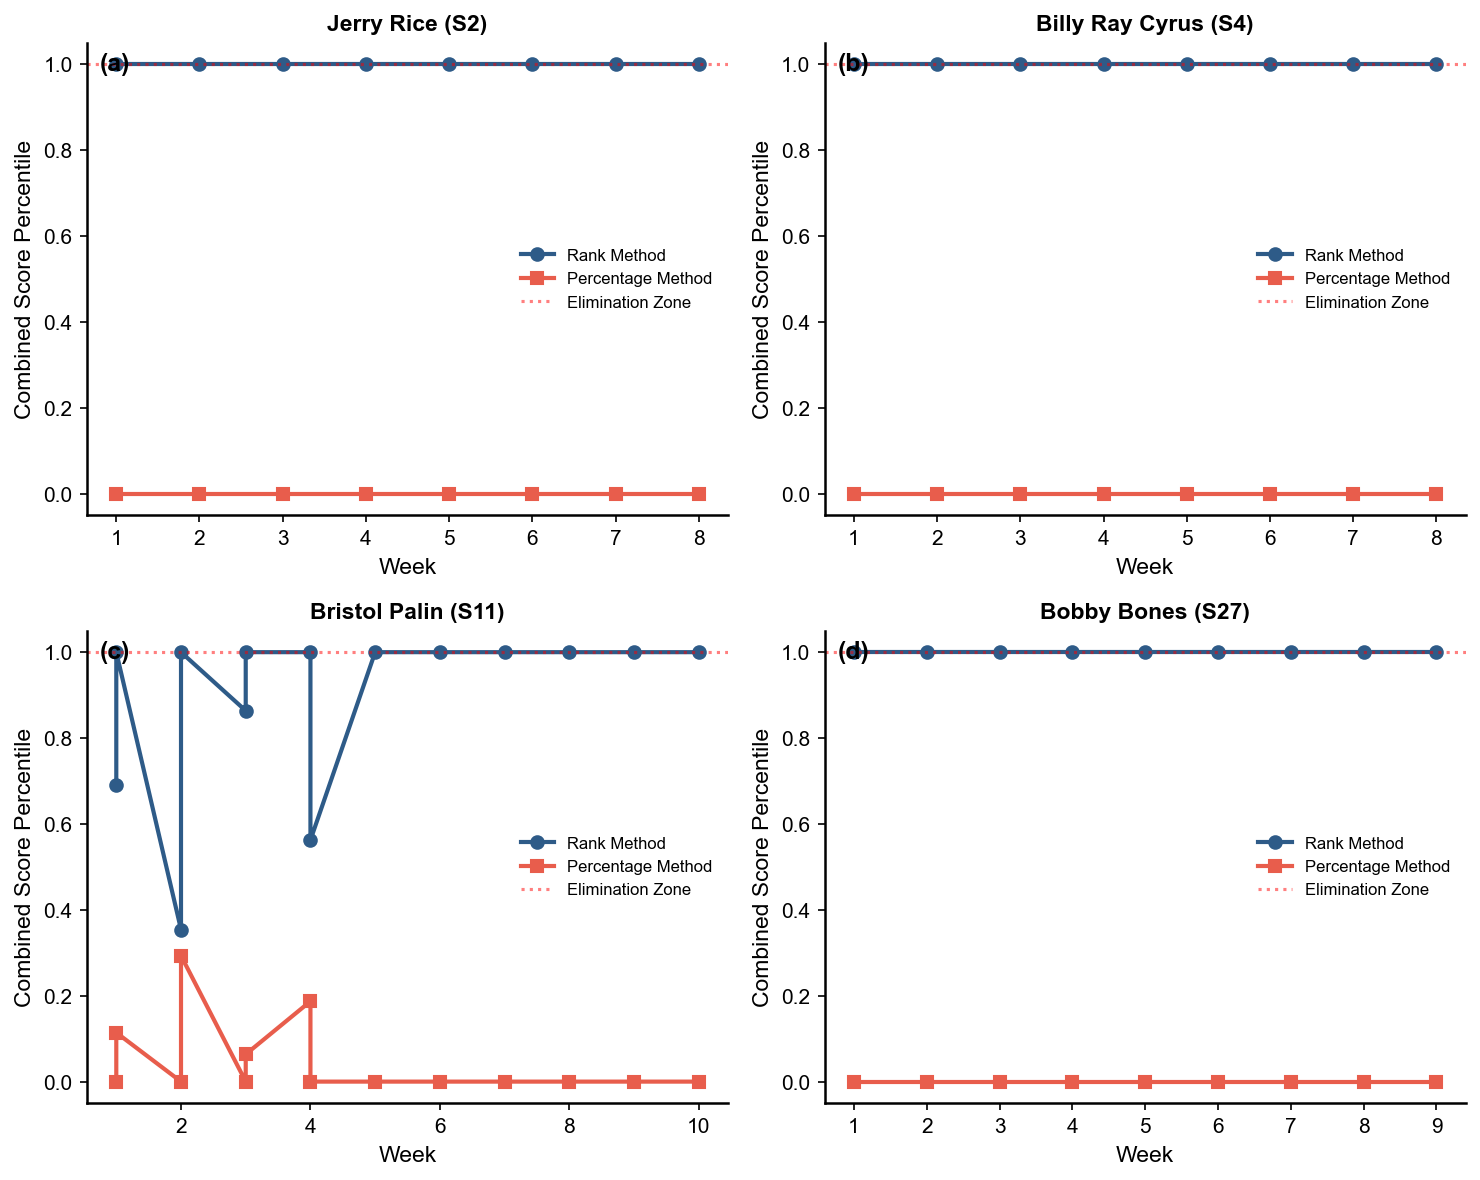

【图2数据特征 - 争议选手】
   Jerry Rice: 最终第2名, 评委平均排名4.6
   Billy Ray Cyrus: 最终第5名, 评委平均排名6.5
   Bristol Palin: 最终第3名, 评委平均排名7.2
   Bobby Bones: 最终第1名, 评委平均排名7.0


In [9]:
# ============ 图2: 争议选手两种方法对比 ============
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, name in enumerate(controversial):
    data = df_compared[df_compared['celebrity_name'] == name].sort_values('week')
    if len(data) > 0:
        weeks = data['week'].values
        
        rank_positions = data['rank_combined'].values / data.groupby('week')['rank_combined'].transform('max').values
        pct_positions = 1 - (data['pct_combined'].values / data.groupby('week')['pct_combined'].transform('max').values)
        
        axes[i].plot(weeks, rank_positions, marker='o', color=COLORS['primary'], 
                    linewidth=2, markersize=6, label='Rank Method')
        axes[i].plot(weeks, pct_positions, marker='s', color=COLORS['secondary'], 
                    linewidth=2, markersize=6, label='Percentage Method')
        
        axes[i].axhline(y=1, color='red', linestyle=':', alpha=0.5, label='Elimination Zone')
        
        axes[i].set_xlabel('Week')
        axes[i].set_ylabel('Combined Score Percentile')
        season = data['season'].iloc[0]
        axes[i].set_title(f'{name} (S{int(season)})', fontsize=11, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].text(0.02, 0.98, f'({chr(97+i)})', transform=axes[i].transAxes, 
                    fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('figures/fig2_controversial_methods.pdf', format='pdf')
plt.show()

print('='*60)
print('【图2数据特征 - 争议选手】')
for _, row in df_controversial.iterrows():
    print(f'   {row["celebrity"]}: 最终第{int(row["final_placement"])}名, 评委平均排名{row["avg_judge_rank"]:.1f}')
print('='*60)

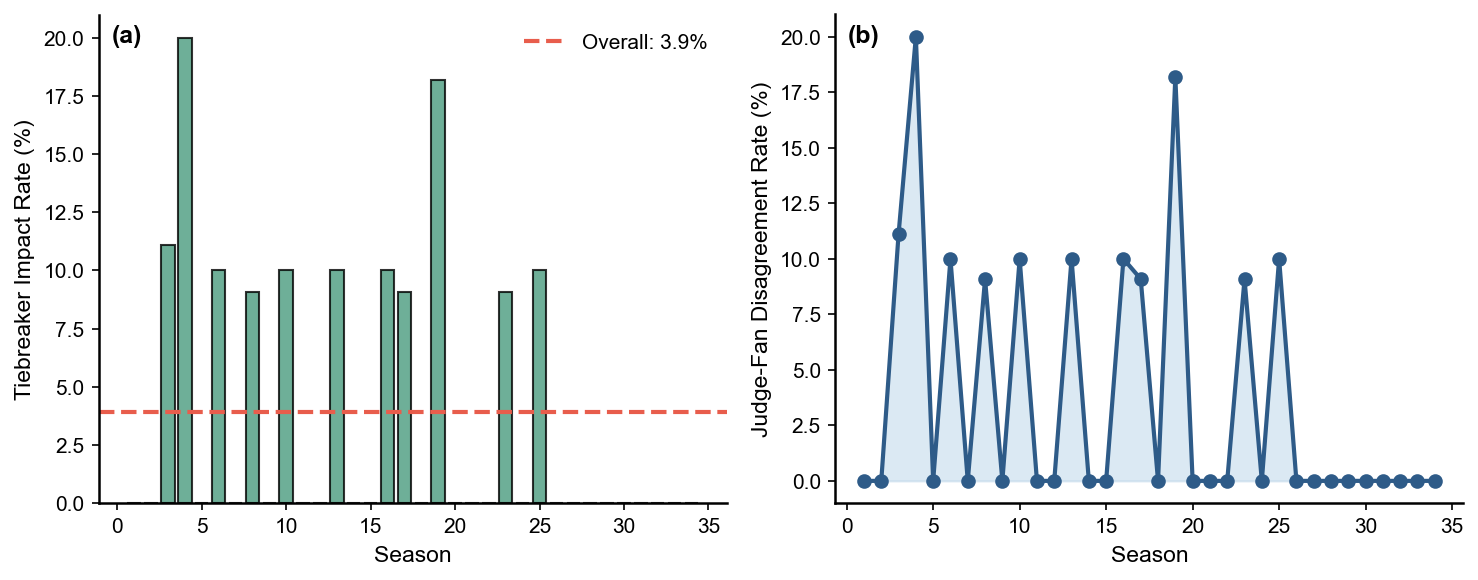

【图3数据特征 - 评委打破平局】
   平均改变结果比例: 3.9%


In [10]:
# ============ 图3: 评委打破平局分析 ============
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

tiebreaker_by_season = tiebreaker_analysis.groupby('season')['tiebreaker_changes_result'].mean() * 100
axes[0].bar(tiebreaker_by_season.index, tiebreaker_by_season.values, 
           color=COLORS['tertiary'], edgecolor='black', alpha=0.8)
axes[0].axhline(y=tiebreaker_analysis['tiebreaker_changes_result'].mean()*100, 
               color=COLORS['secondary'], linestyle='--', linewidth=2,
               label=f'Overall: {tiebreaker_analysis["tiebreaker_changes_result"].mean()*100:.1f}%')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Tiebreaker Impact Rate (%)')
axes[0].legend()
axes[0].text(0.02, 0.98, '(a)', transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')

tiebreaker_diff = tiebreaker_analysis.groupby('season').apply(
    lambda x: (x['judge_tiebreaker_choice'] != x['pure_fan_choice']).mean() * 100
)
axes[1].plot(tiebreaker_diff.index, tiebreaker_diff.values, 
            marker='o', color=COLORS['primary'], linewidth=2, markersize=6)
axes[1].fill_between(tiebreaker_diff.index, 0, tiebreaker_diff.values, 
                    color=COLORS['light'], alpha=0.5)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Judge-Fan Disagreement Rate (%)')
axes[1].text(0.02, 0.98, '(b)', transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('figures/fig3_tiebreaker_analysis.pdf', format='pdf')
plt.show()

print('='*60)
print('【图3数据特征 - 评委打破平局】')
print(f'   平均改变结果比例: {tiebreaker_analysis["tiebreaker_changes_result"].mean()*100:.1f}%')
print('='*60)

## 第八步：结果保存与汇总

In [11]:
# 保存数据
method_diff.to_csv('method_comparison.csv', index=False)
df_controversial.to_csv('controversial_analysis.csv', index=False)
tiebreaker_analysis.to_csv('tiebreaker_analysis.csv', index=False)
bias_analysis.to_csv('bias_analysis.csv', index=False)

print('结果文件已保存')

结果文件已保存


In [12]:
# ============================================================
# 建模结果汇总（供论文引用）
# ============================================================

print("\n" + "="*70)
print("【问题二建模结果汇总】")
print("="*70)

print(f"\n📊 方法比较")
print(f"   两种方法结果一致率: {method_diff['same_method_result'].mean()*100:.1f}%")
print(f"   排名法粉丝影响力: {bias_analysis['rank_fan_influence'].mean():.3f}")
print(f"   百分比法粉丝影响力: {bias_analysis['pct_fan_influence'].mean():.3f}")

print(f"\n🔍 争议选手分析")
for _, row in df_controversial.iterrows():
    print(f"   {row['celebrity']}: 最终第{int(row['final_placement'])}名, 排名法淘汰{int(row['rank_method_eliminations'])}次, 百分比法淘汰{int(row['pct_method_eliminations'])}次")

print(f"\n⚖️ 评委打破平局")
print(f"   改变结果比例: {tiebreaker_analysis['tiebreaker_changes_result'].mean()*100:.1f}%")

print(f"\n📁 生成的图片")
figures = ['fig1_method_comparison.pdf', 'fig2_controversial_methods.pdf', 'fig3_tiebreaker_analysis.pdf']
for i, fig_name in enumerate(figures, 1):
    print(f"   图{i}: {fig_name}")

# 保存汇总
results_summary = {
    'method_agreement_rate': method_diff['same_method_result'].mean(),
    'rank_fan_influence': bias_analysis['rank_fan_influence'].mean(),
    'pct_fan_influence': bias_analysis['pct_fan_influence'].mean(),
    'tiebreaker_impact_rate': tiebreaker_analysis['tiebreaker_changes_result'].mean(),
}
pd.DataFrame([results_summary]).to_csv('results_summary.csv', index=False)

print("\n" + "="*70)
print("✅ 以上数值可直接用于论文撰写")
print("="*70)


【问题二建模结果汇总】

📊 方法比较
   两种方法结果一致率: 95.5%
   排名法粉丝影响力: -0.841
   百分比法粉丝影响力: 0.766

🔍 争议选手分析
   Jerry Rice: 最终第2名, 排名法淘汰3次, 百分比法淘汰3次
   Billy Ray Cyrus: 最终第5名, 排名法淘汰4次, 百分比法淘汰3次
   Bristol Palin: 最终第3名, 排名法淘汰9次, 百分比法淘汰9次
   Bobby Bones: 最终第1名, 排名法淘汰2次, 百分比法淘汰2次

⚖️ 评委打破平局
   改变结果比例: 3.9%

📁 生成的图片
   图1: fig1_method_comparison.pdf
   图2: fig2_controversial_methods.pdf
   图3: fig3_tiebreaker_analysis.pdf

✅ 以上数值可直接用于论文撰写
